In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

df = pd.read_csv("customer_booking.csv", encoding="latin1")

df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [ ]:
print(df.shape) # dimensions of the dataset

df.info() # information about the dataset

df.describe() # it shows the statistical summary of the dataset

(50000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 7.0 MB


,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [5]:
df.isnull().sum()

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [ ]:
df.duplicated().sum() # it shows the number of duplicated rows in the dataset

np.int64(719)

In [ ]:
df = df.drop_duplicates() # it removes the duplicated rows from the dataset

In [10]:
# target variable distribution
df["booking_complete"].value_counts()



booking_complete
0    41890
1     7391
Name: count, dtype: int64

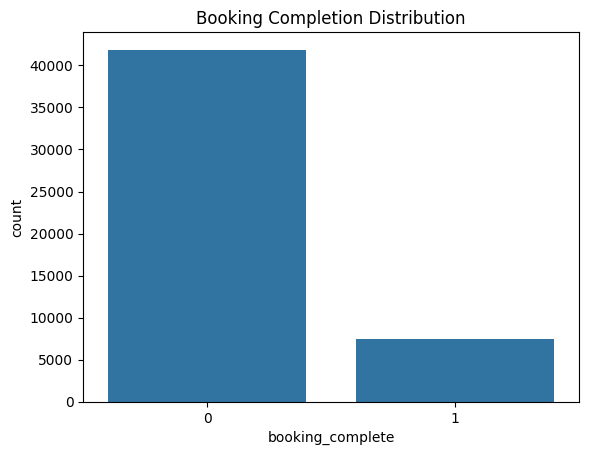

In [ ]:
# target variable distribution

sns.countplot(x="booking_complete", data=df)

plt.title("Booking Completion Distribution")

plt.show()

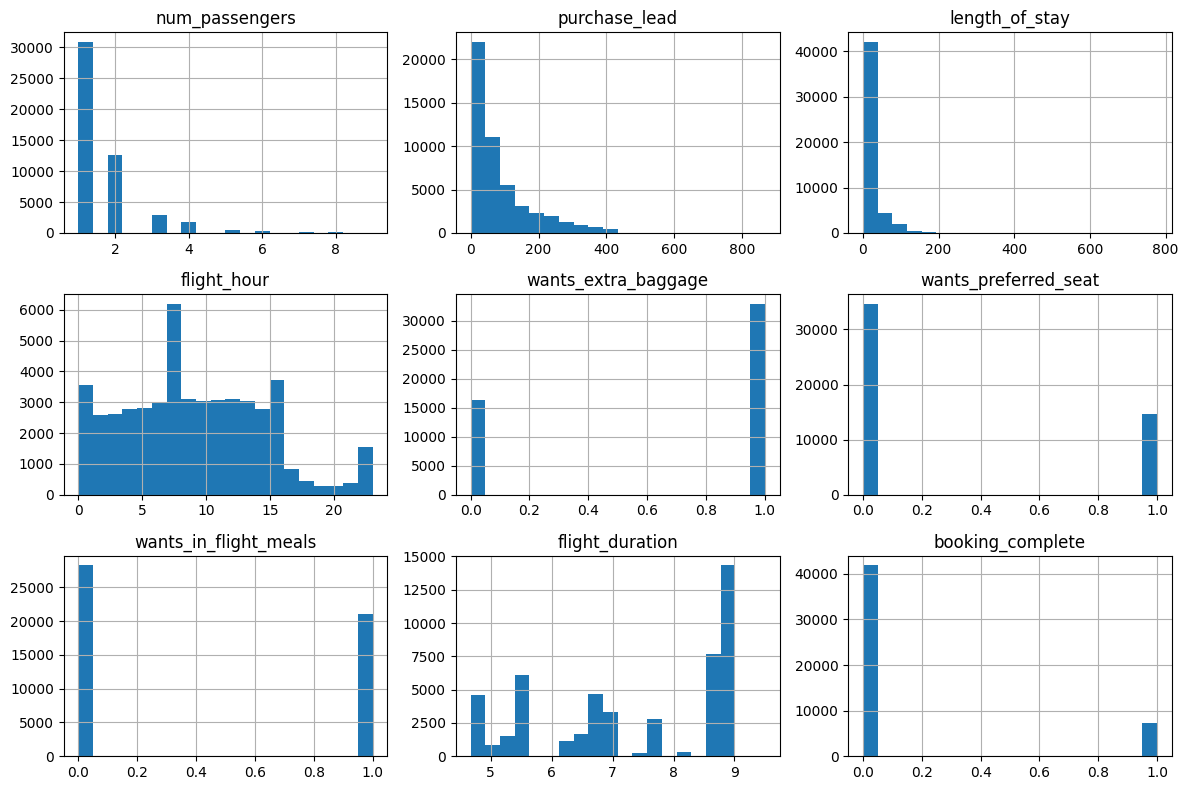

In [ ]:
# numerical features distribution

num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()

plt.show()

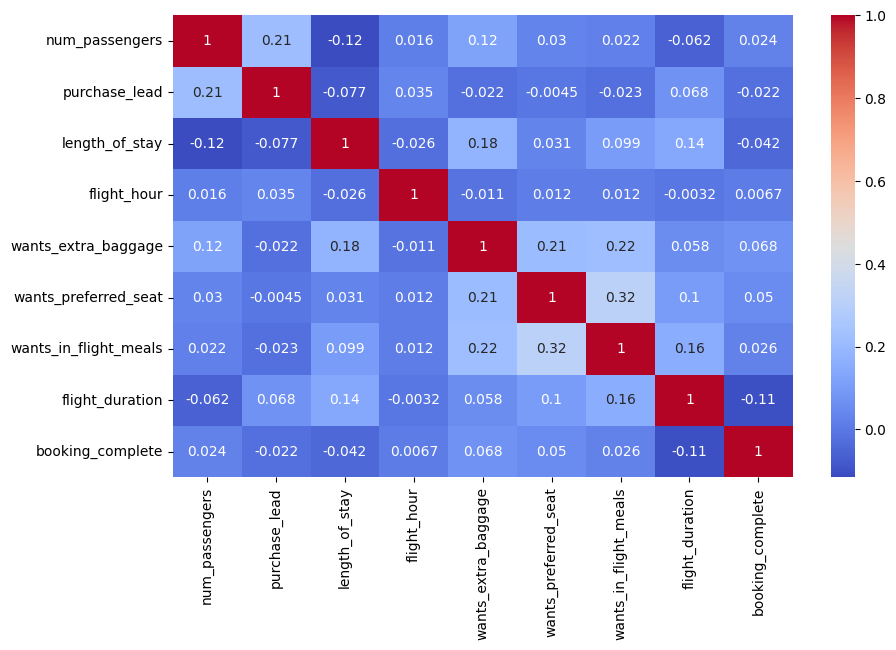

In [ ]:
# correlation heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
# categorical columns

cat_cols = df.select_dtypes(include="object").columns

cat_cols

Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin'], dtype='str')

In [ ]:
# label encoding for categorical variables
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [16]:
X = df.drop("booking_complete", axis=1)

y = df["booking_complete"]

In [ ]:
# train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Random Forest Classifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
y_pred = rf.predict(X_test)

In [ ]:
# Accuracy Score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.8523891650603632


In [21]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8378
           1       0.55      0.10      0.17      1479

    accuracy                           0.85      9857
   macro avg       0.70      0.54      0.54      9857
weighted avg       0.81      0.85      0.81      9857



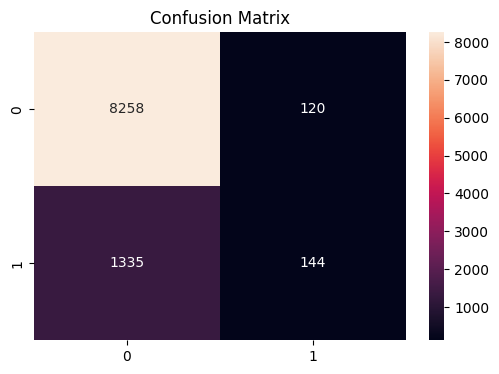

In [22]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

In [23]:
# Cross-validation scores

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5
)

print("CV Scores")

print(cv_scores)

print("Average CV Score")

print(cv_scores.mean())

CV Scores
[0.8504616  0.47554789 0.25355114 0.36576705 0.5367289 ]
Average CV Score
0.4964113136850468


In [ ]:
# feature importance

importance = rf.feature_importances_

feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": importance
    }
)

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,purchase_lead,0.194266
7,route,0.150144
5,flight_hour,0.141749
4,length_of_stay,0.128351
8,booking_origin,0.106006
6,flight_day,0.090568
12,flight_duration,0.071262
0,num_passengers,0.049608
11,wants_in_flight_meals,0.021542
10,wants_preferred_seat,0.017516


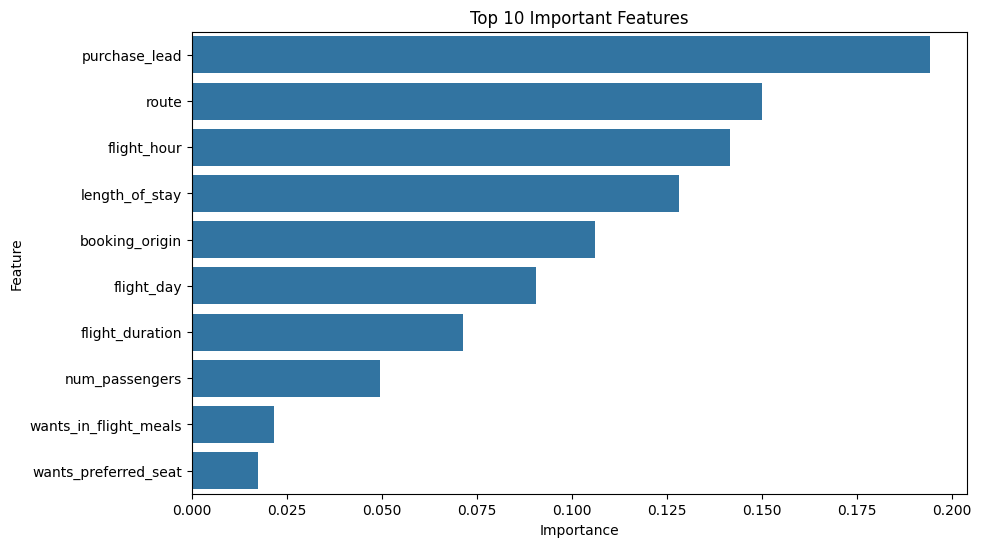

In [ ]:
# display top 10 important features

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Important Features"
)

plt.show()

In [ ]:
# display top 10 important features

print(
feature_importance.head(10)
)

                  Feature  Importance
3           purchase_lead    0.194266
7                   route    0.150144
5             flight_hour    0.141749
4          length_of_stay    0.128351
8          booking_origin    0.106006
6              flight_day    0.090568
12        flight_duration    0.071262
0          num_passengers    0.049608
11  wants_in_flight_meals    0.021542
10   wants_preferred_seat    0.017516


In [ ]:
# 5 customers prediction

for i in range(5):
    customer = X_test.iloc[[i]]

    pred = rf.predict(customer)[0]
    prob = rf.predict_proba(customer)[0]

    print(f"\nCustomer {i+1}")

    if pred == 1:
        print(f"Booking Complete ({prob[1]*100:.2f}%)")
    else:
        print(f"Booking Not Complete ({prob[0]*100:.2f}%)")


Customer 1
Booking Not Complete (75.00%)

Customer 2
Booking Not Complete (76.50%)

Customer 3
Booking Not Complete (99.50%)

Customer 4
Booking Not Complete (82.50%)

Customer 5
Booking Not Complete (85.50%)


In [33]:
# Final Business Insights

print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

top_features = feature_importance.head(5)

print("\nTop 5 Most Important Features:")
print(top_features)

print("\nKey Findings:")
print("1. The model successfully identifies factors influencing booking completion.")
print("2. Customers purchasing additional services (baggage, meals, seats) are more likely to complete bookings.")
print("3. Purchase lead time plays an important role in predicting customer behavior.")
print("4. Flight-related factors such as route and duration contribute to booking decisions.")
print("5. The dataset is imbalanced, with significantly fewer completed bookings than incomplete bookings.")

print("\nBusiness Recommendations:")
print("• Target high-intent customers with personalized marketing campaigns.")
print("• Promote ancillary services such as baggage and meal packages.")
print("• Focus marketing efforts on customer segments with higher booking completion probability.")
print("• Use predictive analytics to improve conversion rates and customer acquisition.")

BUSINESS INSIGHTS

Top 5 Most Important Features:
          Feature  Importance
3   purchase_lead    0.194266
7           route    0.150144
5     flight_hour    0.141749
4  length_of_stay    0.128351
8  booking_origin    0.106006

Key Findings:
1. The model successfully identifies factors influencing booking completion.
2. Customers purchasing additional services (baggage, meals, seats) are more likely to complete bookings.
3. Purchase lead time plays an important role in predicting customer behavior.
4. Flight-related factors such as route and duration contribute to booking decisions.
5. The dataset is imbalanced, with significantly fewer completed bookings than incomplete bookings.

Business Recommendations:
• Target high-intent customers with personalized marketing campaigns.
• Promote ancillary services such as baggage and meal packages.
• Focus marketing efforts on customer segments with higher booking completion probability.
• Use predictive analytics to improve conversion rates 